# JOIN SEVERAL CSV FILES INTO A SINGLE DATAFRAME THAT WE CAN ANALYZE AND WORK WITH

In [254]:
import sys
print(sys.executable)

/usr/bin/python


In [255]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib

In [256]:
#copied over from another file
def removeEmptyRows(cols, df):
    df.dropna(subset=cols, how='all', inplace=True)

In [257]:
def plotColsOnMap(cols,df, log_range = False, mult = 1):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        #we want to see the coastlines on the globe and only take not null values
        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]

        #this sets the logorithmic scale to be exactly like in the paper instead of default
        norm = matplotlib.colors.LogNorm(vmin=1e3, vmax=1e11)
        if(not log_range):
            norm = None

        #scatter plot is created
        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col]*mult,
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree(),
            norm=norm
        )

        #we want to see the entire globe and not just the values 
        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        label = "nifH Gene (copies m-3" if "nifH Gene (copies m-3)" in col else ""

        plt.colorbar(sc, ax=ax, label=label)
        ax.set_title(col.replace("x106 ",""))

    plt.tight_layout()
    plt.show()

In [258]:
def histCols(cols,df, log_range = False, transf = (lambda x: x)):
    #the index is reset from using lat and lon just in case
    df_reset = df.reset_index()

    #the number of rows varies depending on the number of columns to plot
    rows = (len(cols)//2) + (len(cols)%2==1)

    #a set of subplots is created
    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4))

    #we plot each column
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]#subplot

        valid_data = df_reset[df_reset[col].notna()]
        transf(valid_data[col]).hist(bins=50, ax=ax)

        ax.set_title(col)

    plt.tight_layout()
    plt.show()

## We load the data into the notebook
I want to use combined environmental data from the joined csv file as well as avg file to create the model.

In [259]:
cor_cols = ["LATITUDE","LONGITUDE"]

env_data = pd.read_csv("./csv/filled/env_data_all_fill.csv")
bact_data = pd.read_csv("./csv/features/bact_data_avg2.csv")

env_cols = env_data.columns
bact_cols = bact_data.columns

env_cols_data = ['O2_knn', 'T_knn','N_knn', 'P_knn']
bact_cols_data = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)','Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)','Gamma A nifH Gene (x106 copies/m3)']

print(env_cols)
print(bact_cols)
print(set(env_cols.intersection(set(bact_cols))))

env_data.head()

Index(['LATITUDE', 'LONGITUDE', 'O2_simple', 'T_simple', 'N_simple',
       'P_simple', 'O2_lat', 'T_lat', 'N_lat', 'P_lat', 'O2_knn', 'T_knn',
       'N_knn', 'P_knn'],
      dtype='object')
Index(['LATITUDE', 'LONGITUDE', 'Unnamed: 0',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)',
       'Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)',
       'Gamma A nifH Gene (x106 copies/m3)'],
      dtype='object')
{'LONGITUDE', 'LATITUDE'}


,LATITUDE,LONGITUDE,O2_simple,T_simple,N_simple,P_simple,O2_lat,T_lat,N_lat,P_lat,O2_knn,T_knn,N_knn,P_knn
0,-78.0,-178.0,363.257667,-1.000333,20.086000,1.376833,363.257667,-1.000333,20.086000,1.376833,363.257667,-1.000333,20.086000,1.376833
1,-78.0,-178.0,379.909333,-1.063500,17.256333,1.167833,379.909333,-1.063500,17.256333,1.167833,379.909333,-1.063500,17.256333,1.167833
2,-78.0,-176.0,343.680667,-1.180833,21.673167,1.437667,343.680667,-1.180833,21.673167,1.437667,343.680667,-1.180833,21.673167,1.437667
3,-78.0,-176.0,364.647500,-1.164667,21.020667,1.539333,364.647500,-1.164667,21.020667,1.539333,364.647500,-1.164667,21.020667,1.539333
4,-78.0,-174.0,355.757167,-1.360167,18.907667,1.608667,355.757167,-1.360167,18.907667,1.608667,355.757167,-1.360167,18.907667,1.608667


In [260]:
bact_data.head()

,LATITUDE,LONGITUDE,Unnamed: 0,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3),Gamma A nifH Gene (x106 copies/m3)
0,-76.0,34.0,5576.0,0.329000,NaN,NaN,NaN,NaN
1,-76.0,35.0,5574.0,0.057000,NaN,NaN,NaN,NaN
2,-75.0,35.0,5571.5,0.103500,NaN,NaN,NaN,NaN
3,-74.0,35.0,5566.0,1.635286,NaN,NaN,NaN,NaN
4,-74.0,36.0,5558.0,7.797333,NaN,NaN,NaN,NaN


In [261]:
env_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40567 entries, 0 to 40566
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LATITUDE   40567 non-null  float64
 1   LONGITUDE  40567 non-null  float64
 2   O2_simple  40567 non-null  float64
 3   T_simple   40567 non-null  float64
 4   N_simple   40567 non-null  float64
 5   P_simple   40567 non-null  float64
 6   O2_lat     40567 non-null  float64
 7   T_lat      40567 non-null  float64
 8   N_lat      40567 non-null  float64
 9   P_lat      40567 non-null  float64
 10  O2_knn     40567 non-null  float64
 11  T_knn      40567 non-null  float64
 12  N_knn      40567 non-null  float64
 13  P_knn      40567 non-null  float64
dtypes: float64(14)
memory usage: 4.3 MB


In [262]:
bact_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 8 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   LATITUDE                                              1025 non-null   float64
 1   LONGITUDE                                             1025 non-null   float64
 2   Unnamed: 0                                            1025 non-null   float64
 3   Trichodesmium nifH Gene (x106 copies m-3)             811 non-null    float64
 4   UCYN-A nifH Gene (x106 copies m-3)                    844 non-null    float64
 5   UCYN-B nifH Gene (x106 copies m-3)                    498 non-null    float64
 6   Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)  117 non-null    float64
 7   Gamma A nifH Gene (x106 copies/m3)                    69 non-null     float64
dtypes: float64(8)
memory usage: 64.2 KB


## Joining them together
In order to concatenate the dataframes we need to set index to the coordinate columns.

In [263]:
#I noticed there was an unnamed column, likely averaged depth
bact_data = bact_data.drop(columns=['Unnamed: 0'])

#used pd merge
combined_df = pd.merge(env_data, bact_data, on=['LATITUDE', 'LONGITUDE'], how='inner')
combined_df.head()

,LATITUDE,LONGITUDE,O2_simple,T_simple,N_simple,P_simple,O2_lat,T_lat,N_lat,P_lat,O2_knn,T_knn,N_knn,P_knn,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3),Gamma A nifH Gene (x106 copies/m3)
0,-68.0,36.0,351.323667,-1.451500,20.356667,1.450500,351.323667,-1.451500,20.356667,1.450500,351.323667,-1.451500,20.356667,1.450500,NaN,128.8,NaN,NaN,NaN
1,-68.0,36.0,338.203333,-1.206500,27.317000,1.915500,338.203333,-1.206500,27.317000,1.915500,338.203333,-1.206500,27.317000,1.915500,NaN,128.8,NaN,NaN,NaN
2,-68.0,36.0,342.457500,-1.258167,22.296167,1.620000,342.457500,-1.258167,22.296167,1.620000,342.457500,-1.258167,22.296167,1.620000,NaN,128.8,NaN,NaN,NaN
3,-68.0,36.0,339.693667,-1.239167,26.114167,1.913500,339.693667,-1.239167,26.114167,1.913500,339.693667,-1.239167,26.114167,1.913500,NaN,128.8,NaN,NaN,NaN
4,-60.0,110.0,347.342500,0.222167,5.452691,0.566445,347.342500,0.222167,24.658427,1.628623,347.342500,0.222167,26.968633,1.579591,NaN,83.6,NaN,NaN,NaN


In [264]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132 entries, 0 to 1131
Data columns (total 19 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   LATITUDE                                              1132 non-null   float64
 1   LONGITUDE                                             1132 non-null   float64
 2   O2_simple                                             1132 non-null   float64
 3   T_simple                                              1132 non-null   float64
 4   N_simple                                              1132 non-null   float64
 5   P_simple                                              1132 non-null   float64
 6   O2_lat                                                1132 non-null   float64
 7   T_lat                                                 1132 non-null   float64
 8   N_lat                                                 1132

## Map plots of resulting data
We know that the resulting set of points is the subset of environmental points from the inital dataset. So, I thought that we should see a clear picture of the data that we are going to be training on and keeping.

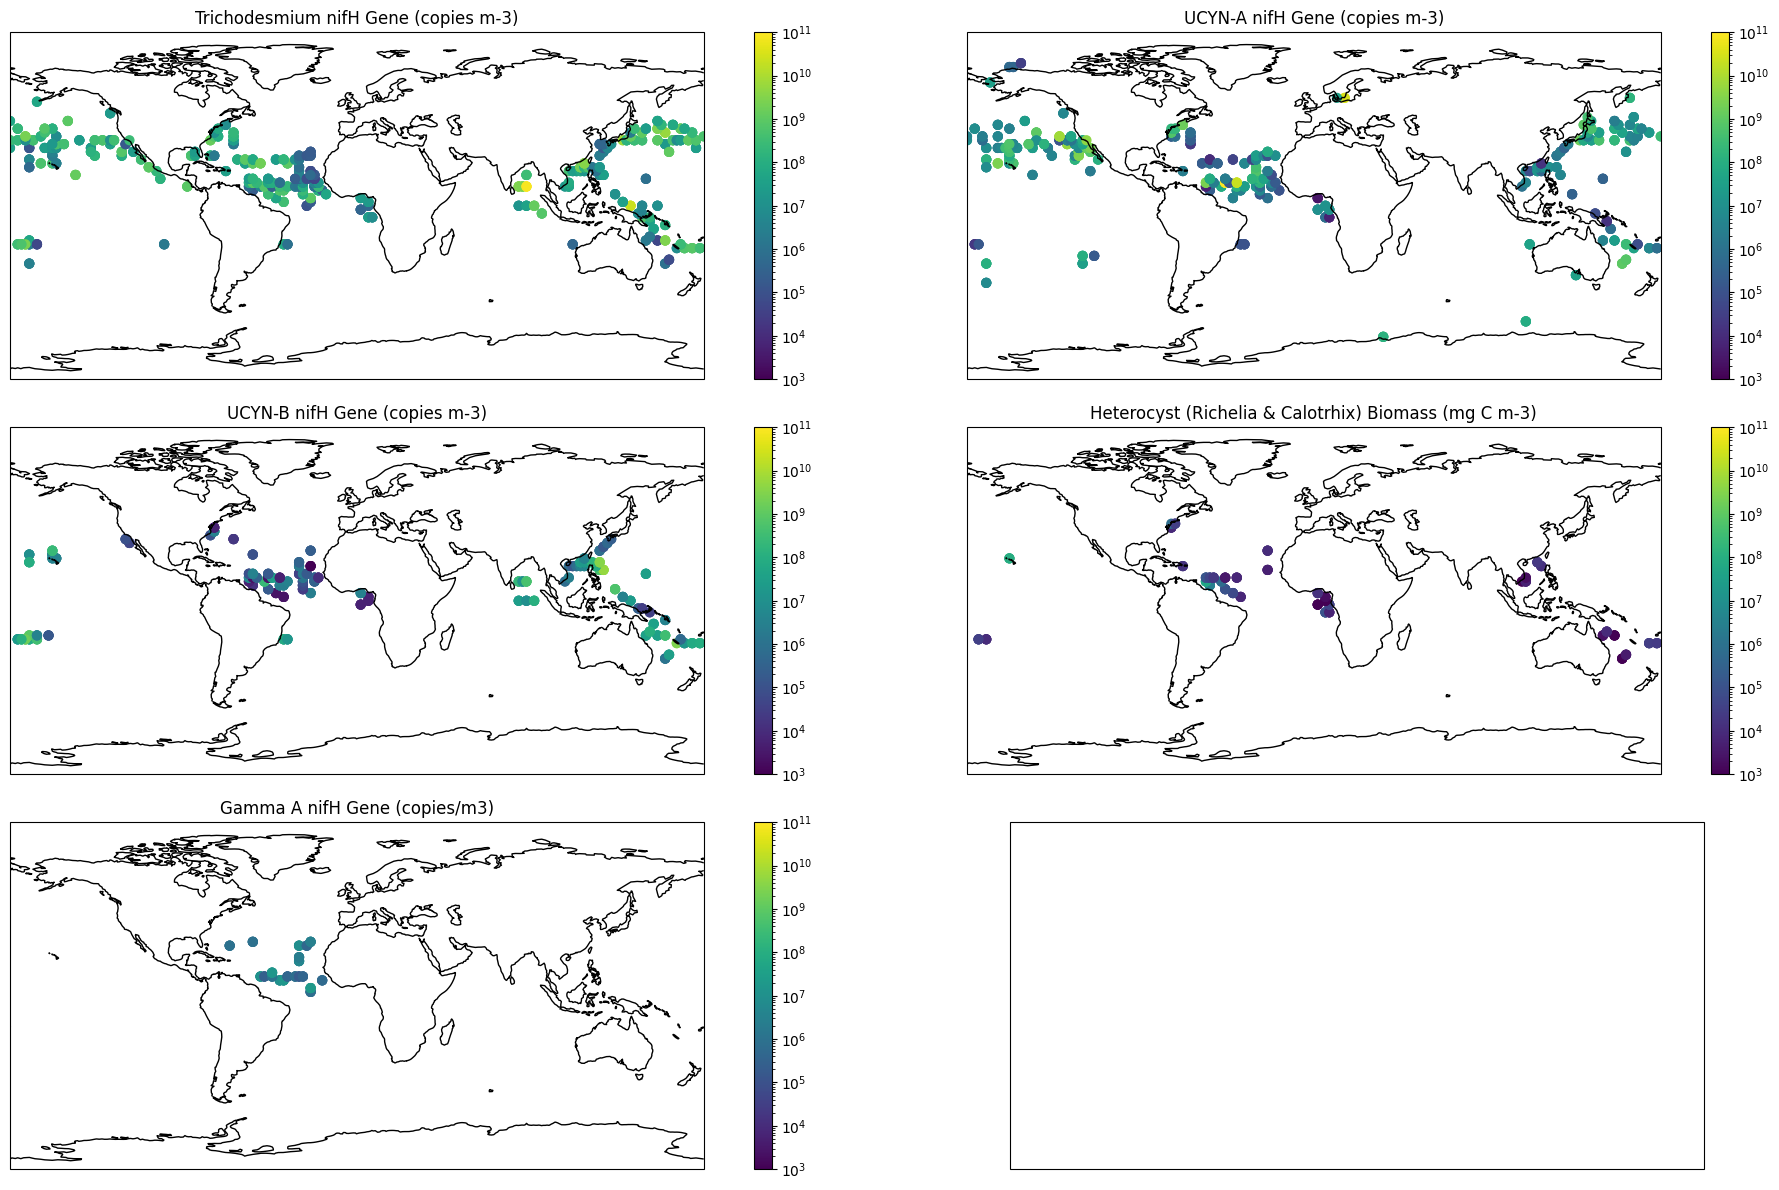

In [265]:
plotColsOnMap(bact_cols_data, combined_df, log_range=True, mult=10**6)

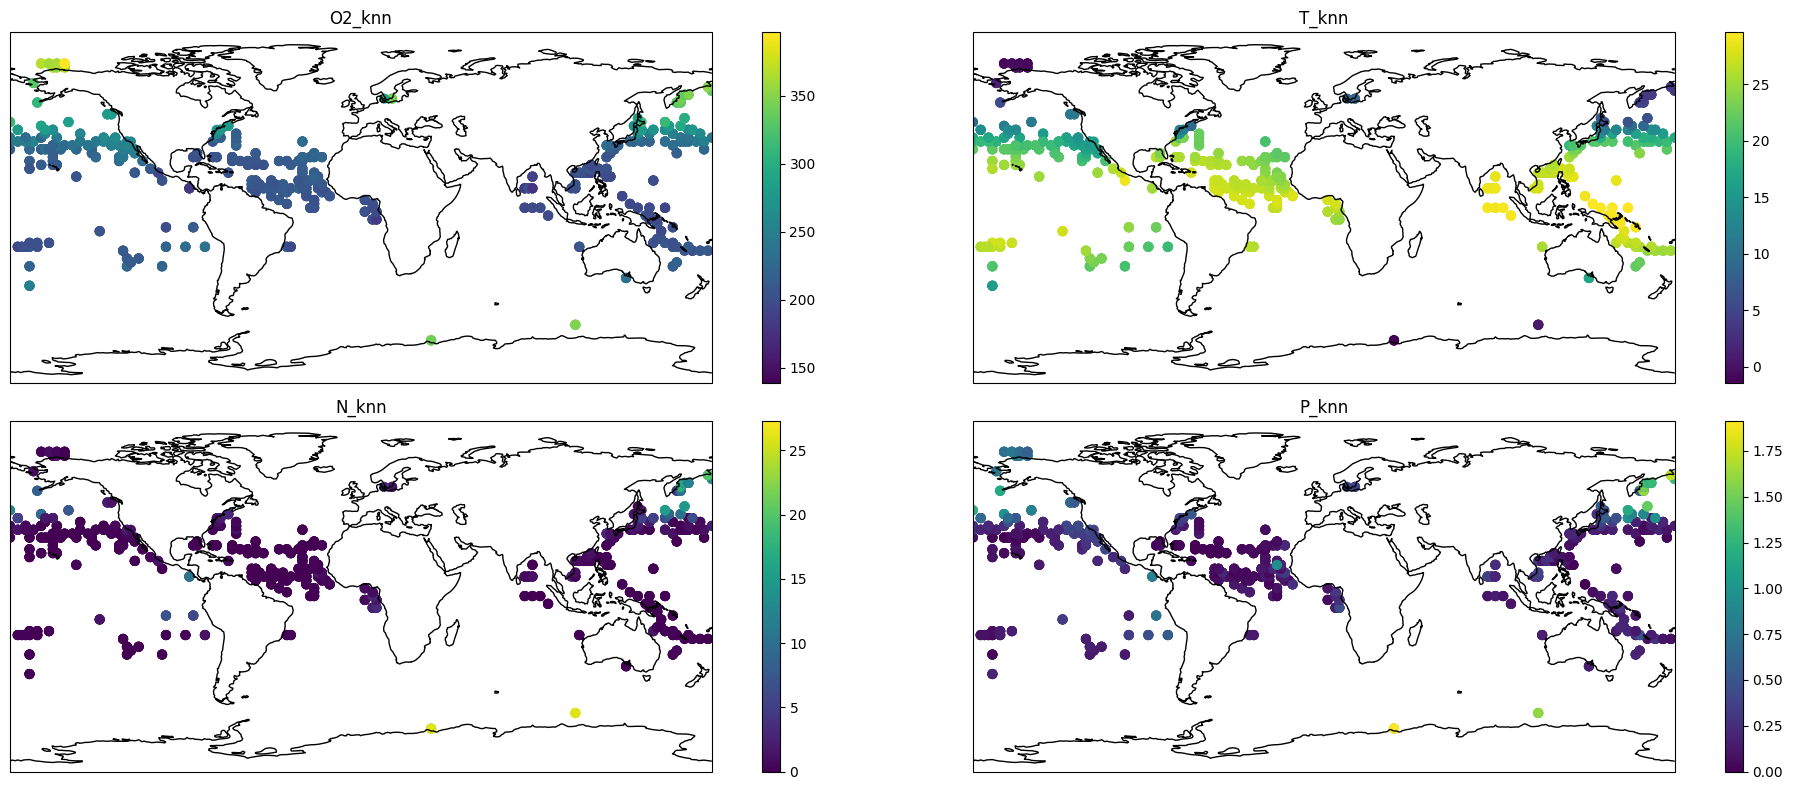

In [266]:
plotColsOnMap(env_cols_data, combined_df)

## Histograms
It is also important to see in what range and how different values are distributed.

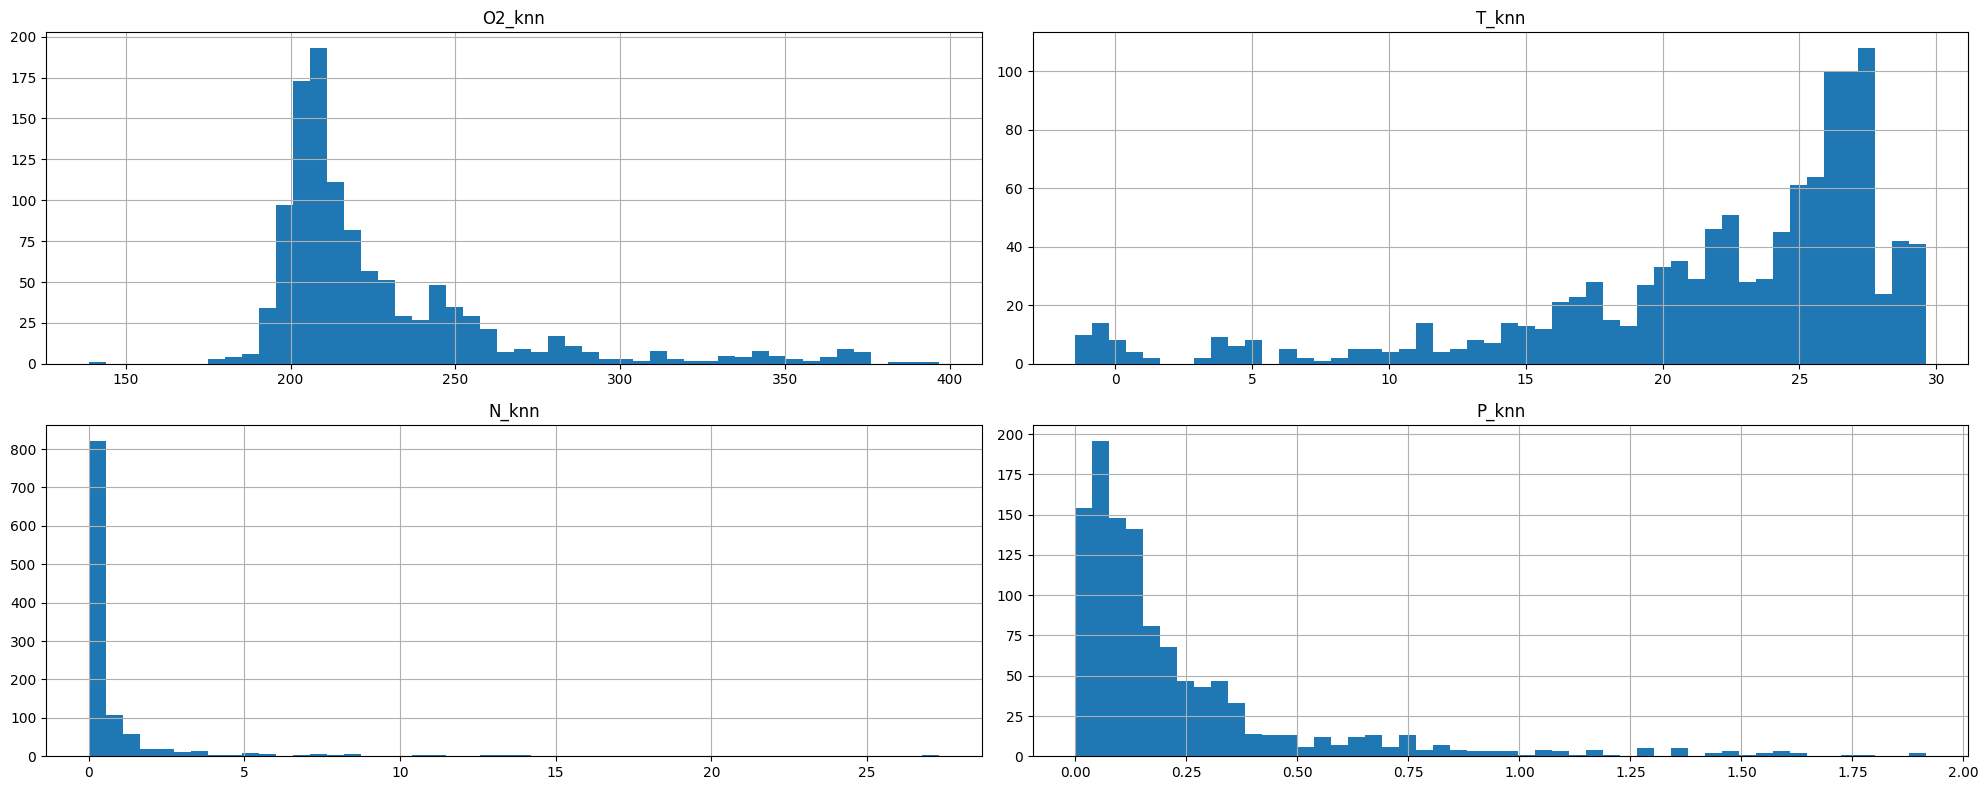

In [267]:
histCols(env_cols_data, combined_df)

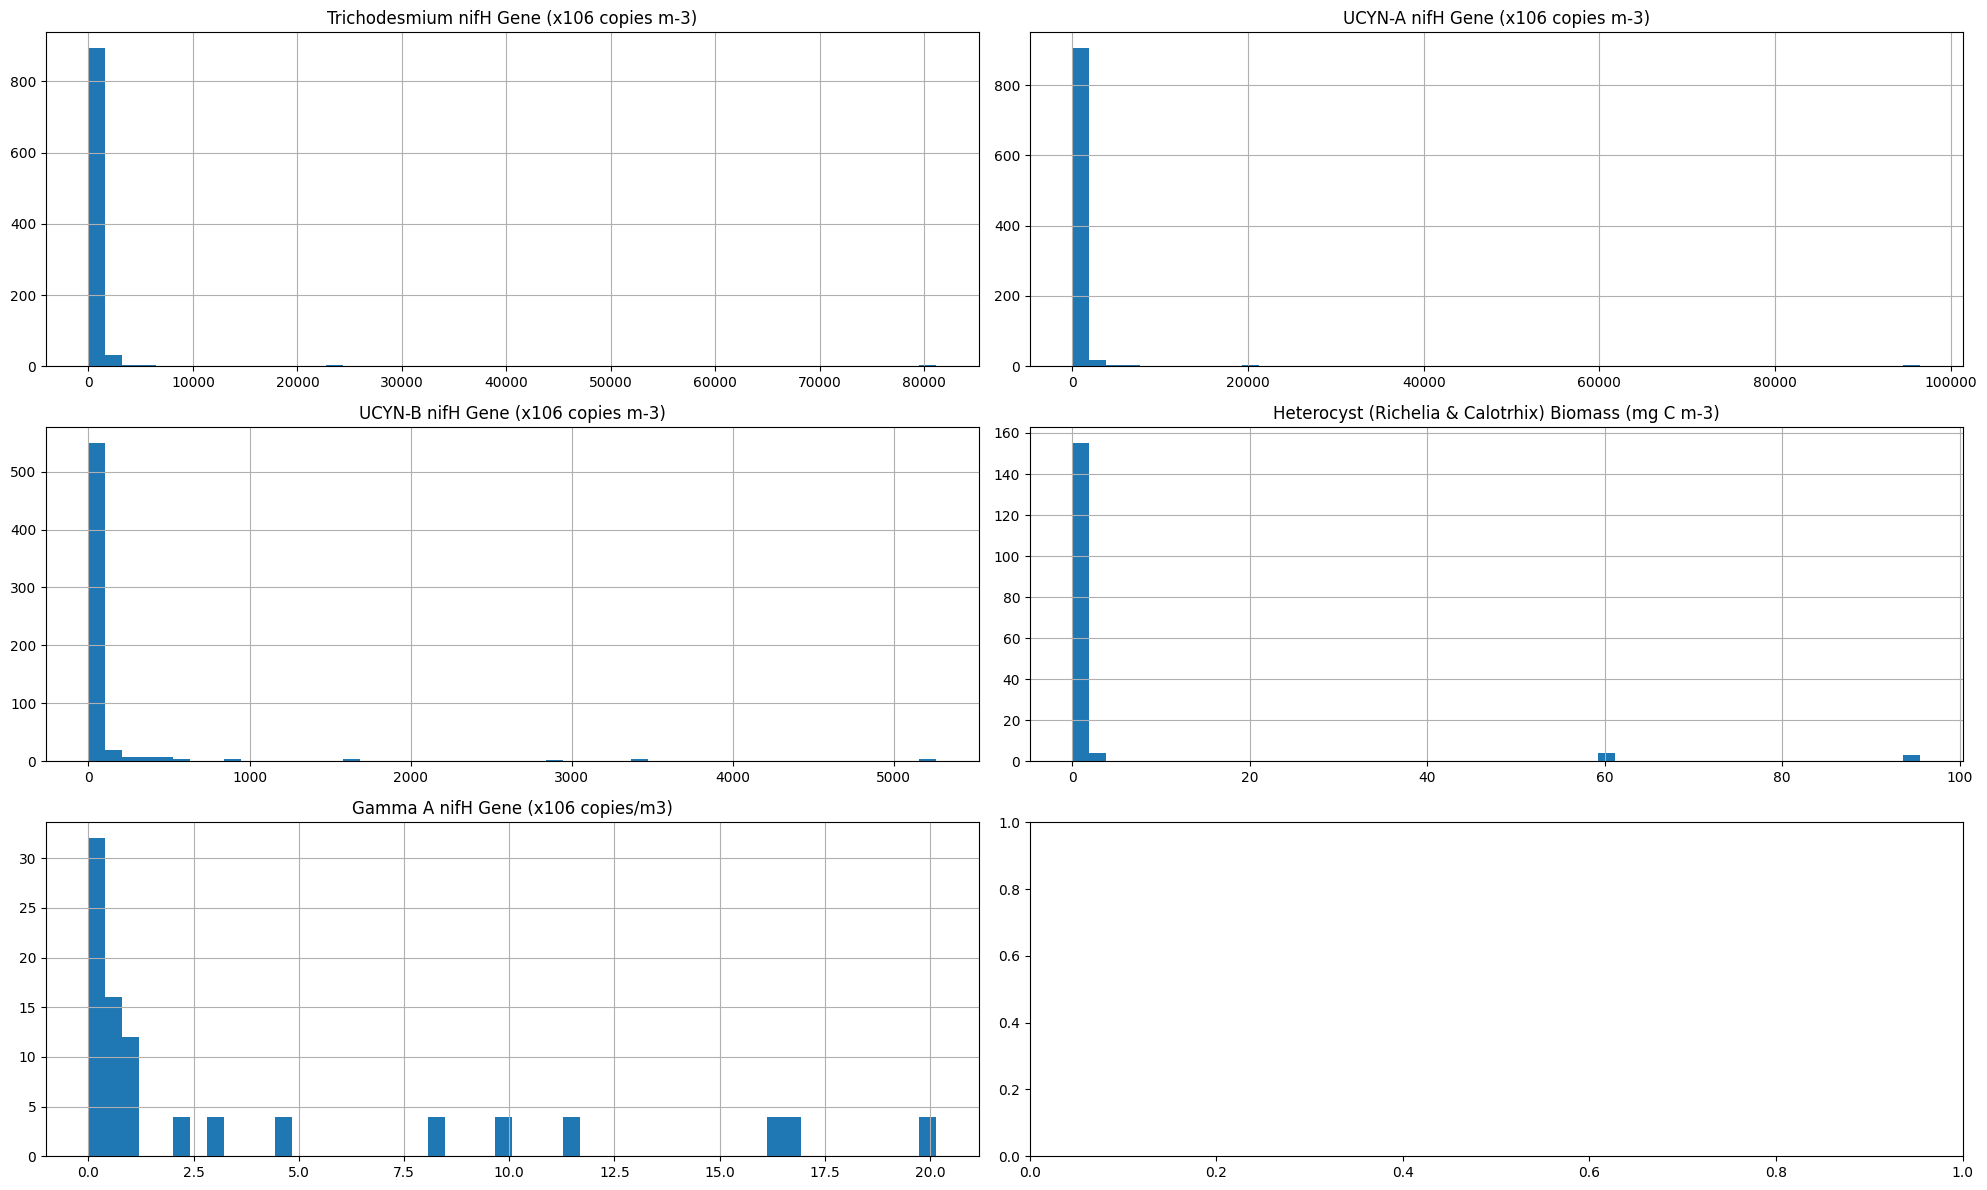

In [268]:
histCols(bact_cols_data, combined_df)

We can see that the values are very skewed and taking logorithm after multiplying it might help make the distribution a bit more like normal.

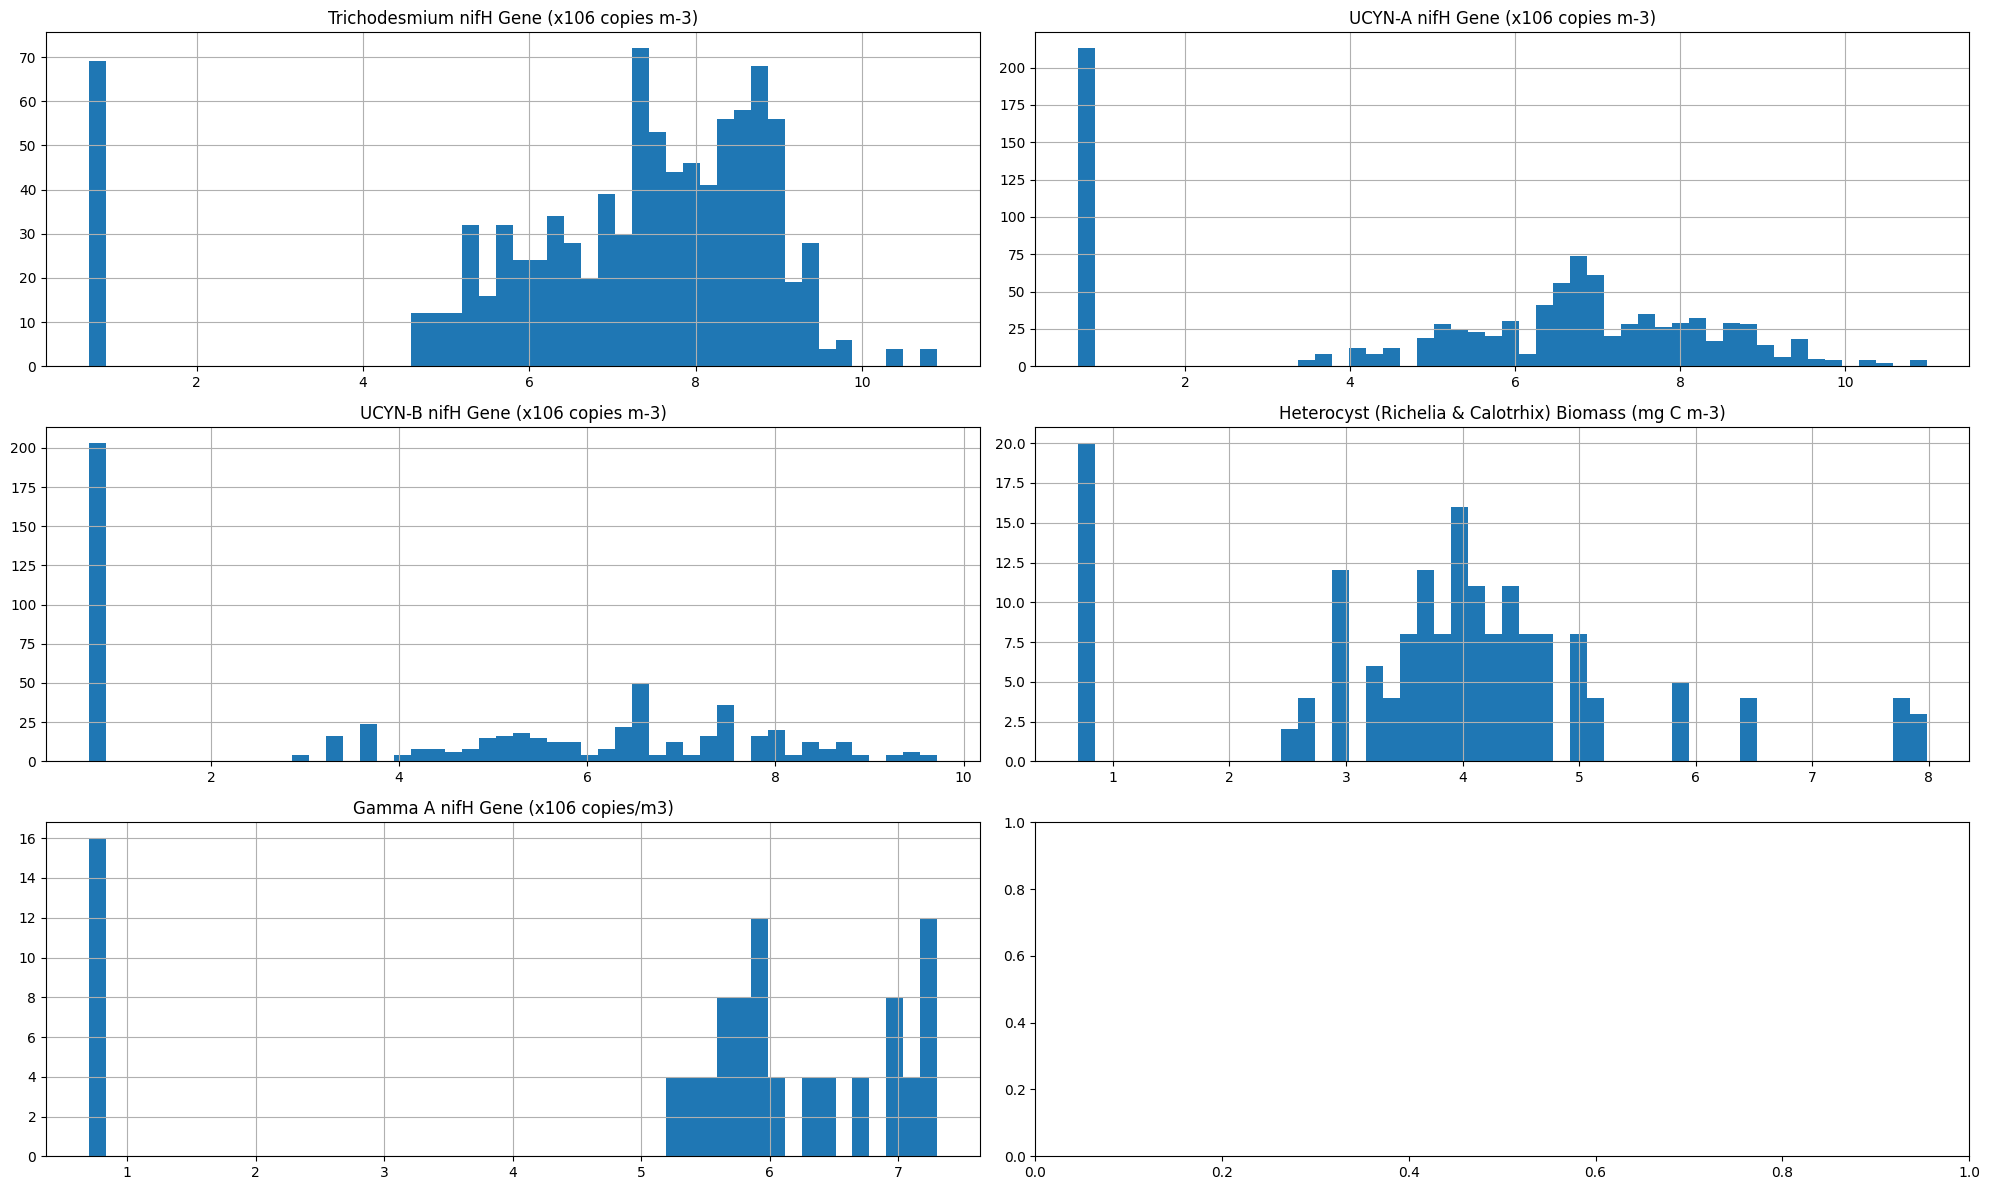

In [269]:
histCols(bact_cols_data, combined_df, transf=(lambda x: np.log10(x*(10**6)+5)))